## =============| Heart Disease |=============
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [2]:
df = pd.read_csv(r"E:\Data set\heart_disease.csv")

In [3]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [4]:
df.shape

(10000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [6]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

In [7]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [8]:
df.isna().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [9]:
df.isna().sum()/df.shape[0]*100

Age                      0.29
Gender                   0.19
Blood Pressure           0.19
Cholesterol Level        0.30
Exercise Habits          0.25
Smoking                  0.25
Family Heart Disease     0.21
Diabetes                 0.30
BMI                      0.22
High Blood Pressure      0.26
Low HDL Cholesterol      0.25
High LDL Cholesterol     0.26
Alcohol Consumption     25.86
Stress Level             0.22
Sleep Hours              0.25
Sugar Consumption        0.30
Triglyceride Level       0.26
Fasting Blood Sugar      0.22
CRP Level                0.26
Homocysteine Level       0.20
Heart Disease Status     0.00
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

## Distribution (Categorical vs Numerical)

In [11]:
nos_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_col = df.select_dtypes(include=['bool','object']).columns.tolist()
print(nos_col)
print('*'*50)
print(cat_col)

['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
**************************************************
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']


## Checking Outliers

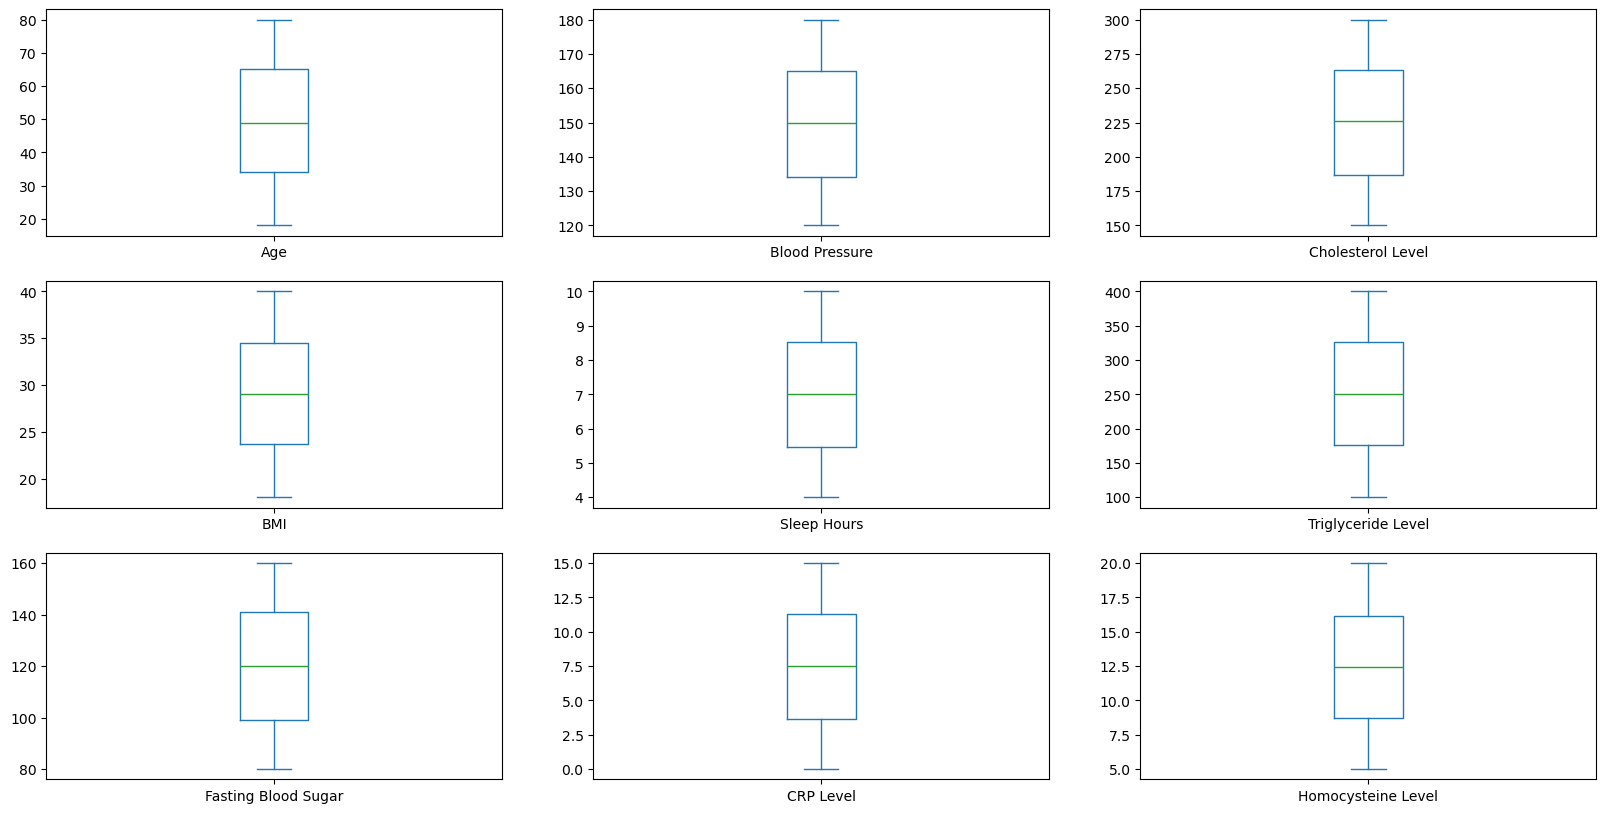

In [12]:
# box plot 
df[nos_col].plot(kind = 'box',subplots =True , layout = (3,3) , figsize = (20,10))
plt.show()

In [13]:
# IQR Quantile Method
for i in nos_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    cline = df[(df[i] <= lower) & (df[i] >= upper)].shape[0]
    print(cline)

0
0
0
0
0
0
0
0
0


### Chek skew for hindling null values 

In [14]:
df.skew(numeric_only=True)

Age                   -0.006789
Blood Pressure         0.013907
Cholesterol Level     -0.007120
BMI                   -0.021342
Sleep Hours            0.000172
Triglyceride Level     0.006142
Fasting Blood Sugar   -0.008915
CRP Level             -0.004069
Homocysteine Level     0.007886
dtype: float64

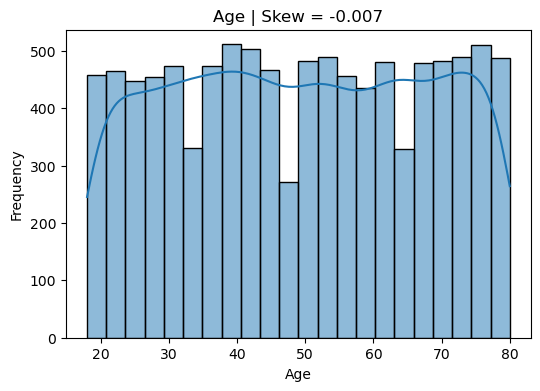

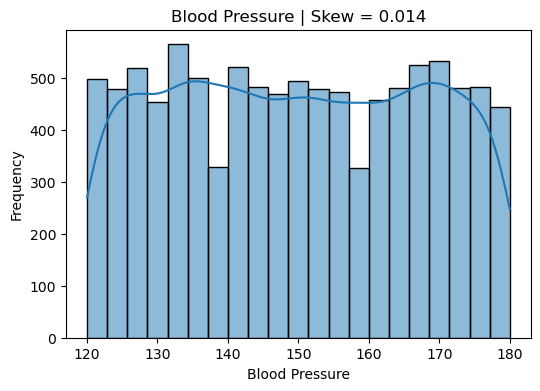

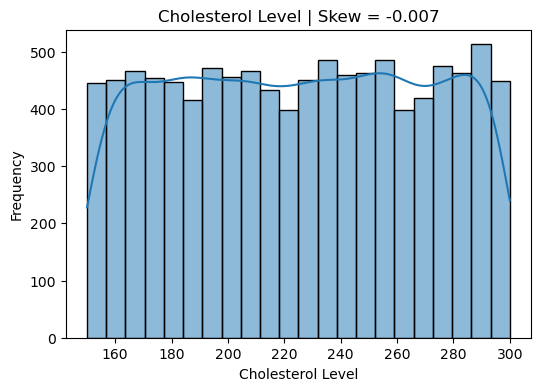

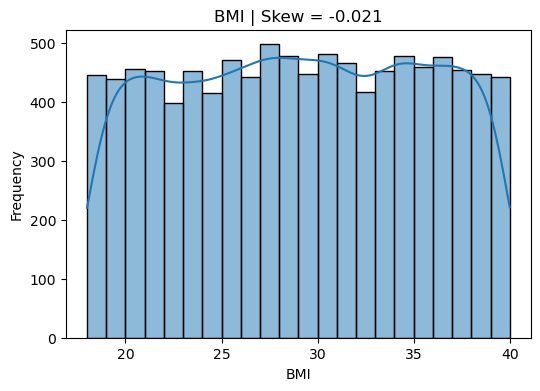

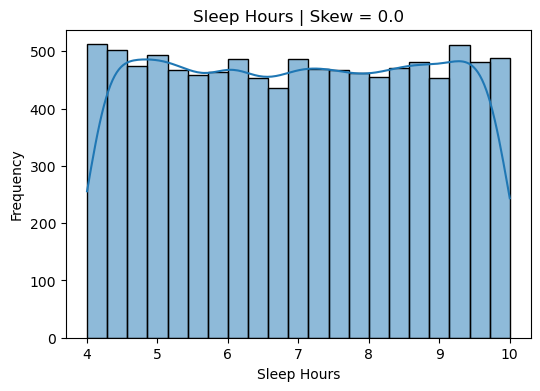

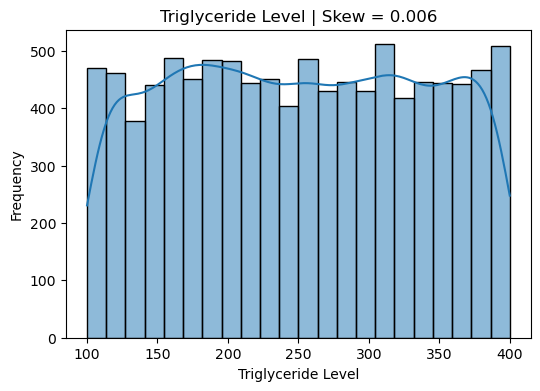

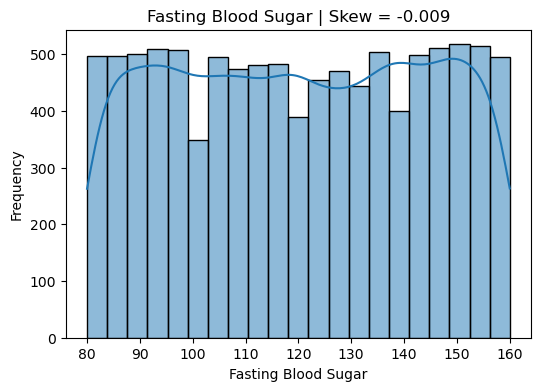

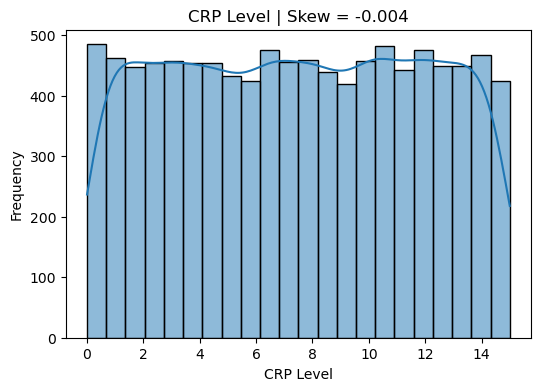

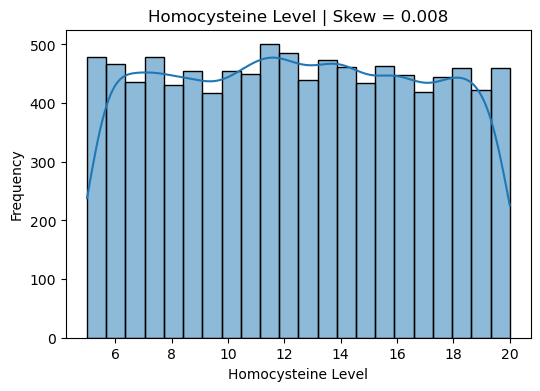

In [15]:
for col in nos_col:
    skew_value = df[col].skew()
    
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    
    plt.title(f"{col} | Skew = {round(skew_value, 3)}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

In [16]:
cols = ['Age','Blood Pressure','Cholesterol Level','BMI','Sleep Hours','Triglyceride Level','Fasting Blood Sugar','CRP Level','Homocysteine Level']
for col in cols:
    df[col] = df[col].fillna(df[col].mean())

In [17]:
cat = ['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes', 'High Blood Pressure','Alcohol Consumption','Stress Level',
       'Sugar Consumption','Low HDL Cholesterol','High LDL Cholesterol']

for catg in cat:
    df[catg] = df[catg].fillna(df[catg].mode()[0])  
    df[catg] = df[catg].astype(str)               
    df[catg] = df[catg].str.replace(r'[^a-zA-Z]', ' ', regex=True)  
    df[catg] = df[catg].str.lower()              

In [18]:
df['Heart Disease Status'].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

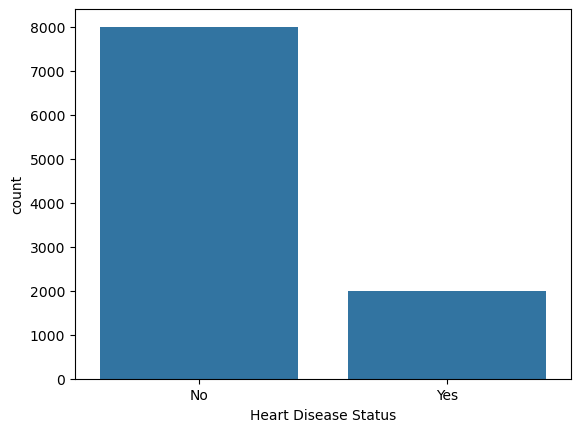

In [19]:
sns.countplot( x = 'Heart Disease Status' ,data =df)
plt.show()

In [20]:
# Chek Ordinal Column 
for ordinal in cat_col:
    print(ordinal, df[ordinal].unique())

Gender ['male' 'female']
Exercise Habits ['high' 'low' 'medium']
Smoking ['yes' 'no']
Family Heart Disease ['yes' 'no']
Diabetes ['no' 'yes']
High Blood Pressure ['yes' 'no']
Low HDL Cholesterol ['yes' 'no']
High LDL Cholesterol ['no' 'yes']
Alcohol Consumption ['high' 'medium' 'low']
Stress Level ['medium' 'high' 'low']
Sugar Consumption ['medium' 'low' 'high']
Heart Disease Status ['No' 'Yes']


## Univariate Analysis On Categorical Columns

### Numerical vs Target

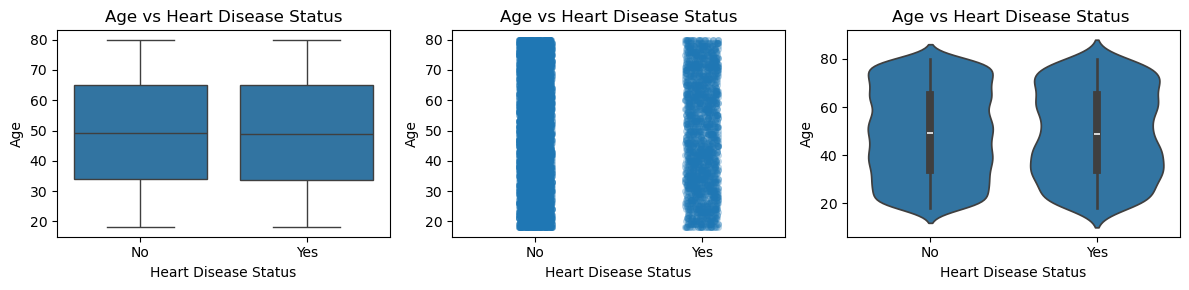

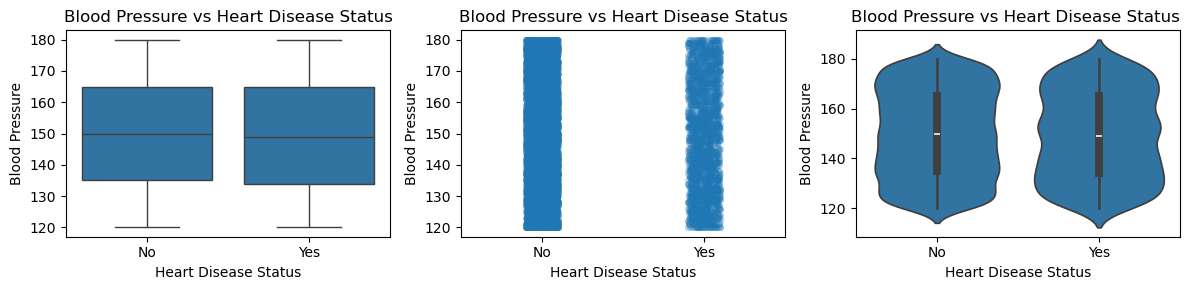

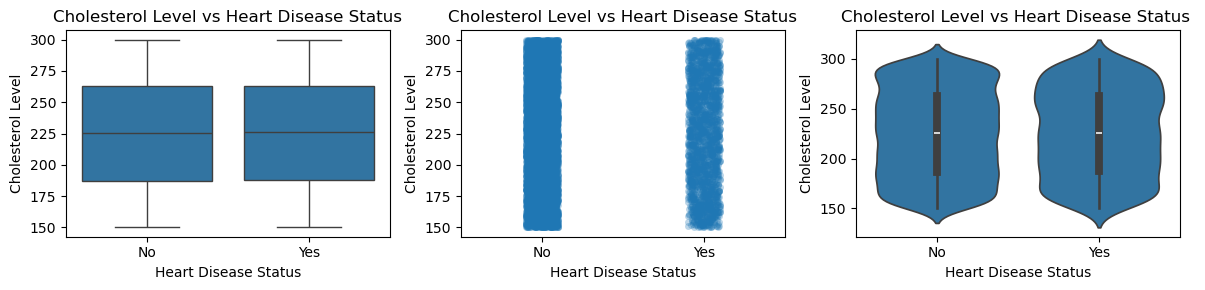

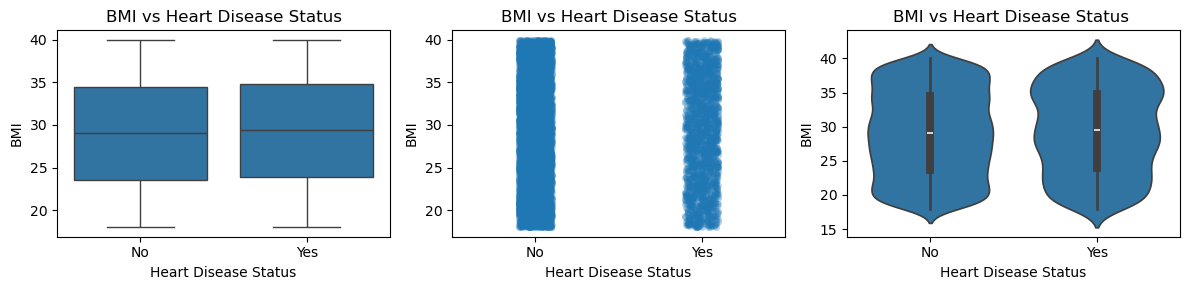

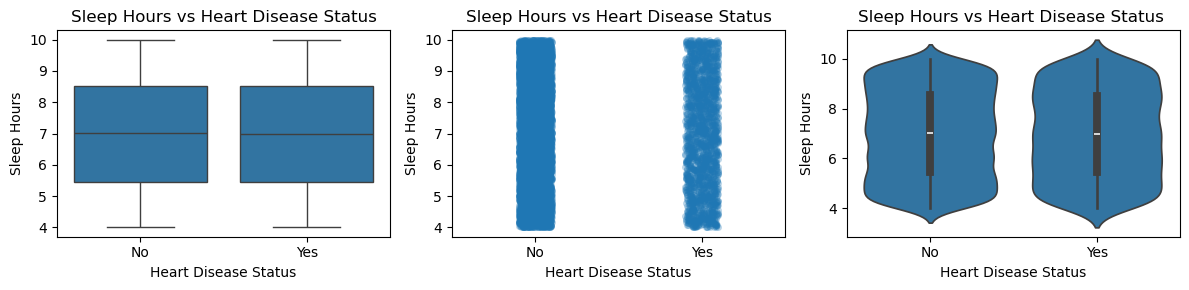

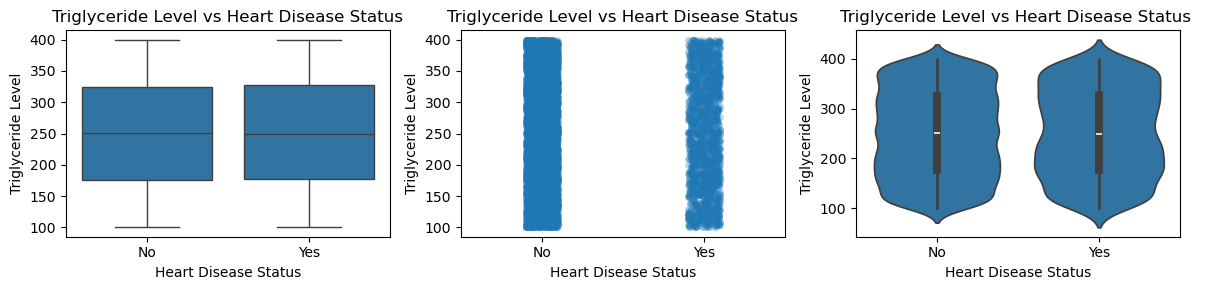

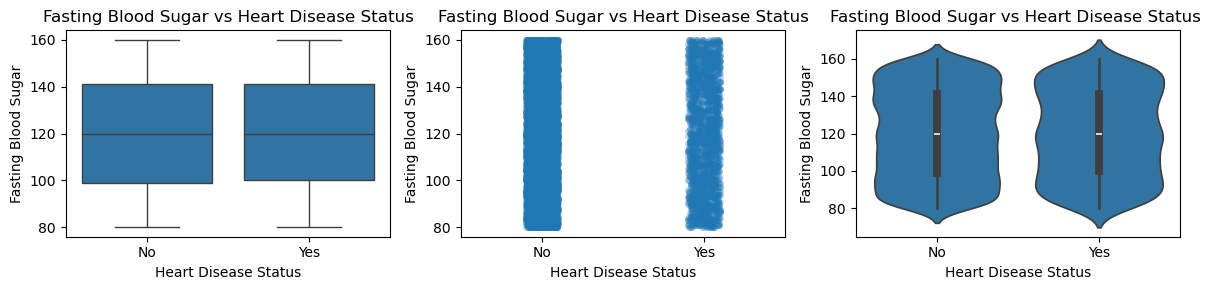

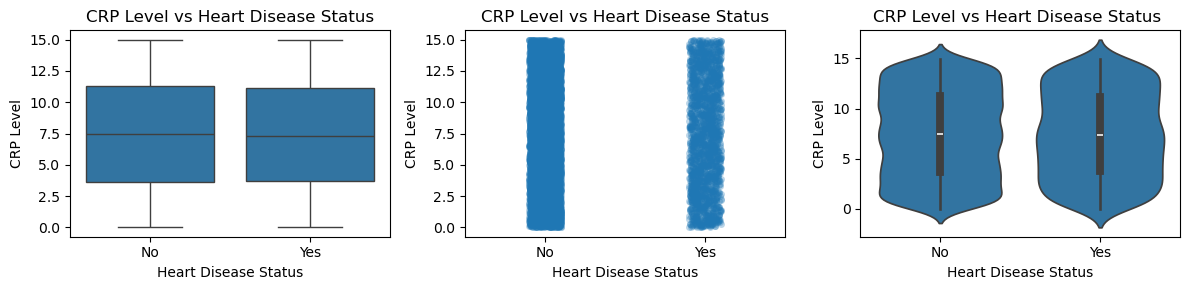

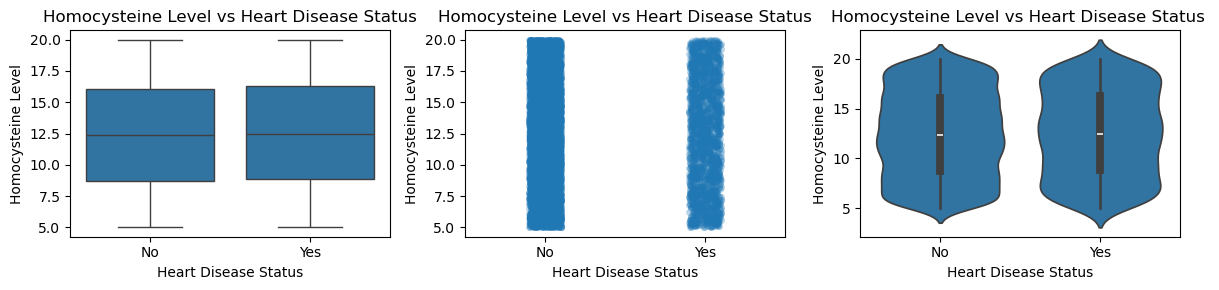

In [21]:
for grap in nos_col:
    plt.figure(figsize=(12,3))
    
    # Boxplot 
    plt.subplot(1,3,1)
    sns.boxplot(x=df['Heart Disease Status'], y=df[grap])
    plt.title(f"{grap} vs Heart Disease Status")
    
    #  Stripplot (scatter alternative)
    plt.subplot(1,3,2)
    sns.stripplot(x=df['Heart Disease Status'], y=df[grap], alpha=0.3)
    plt.title(f"{grap} vs Heart Disease Status")

    plt.subplot(1,3,3)
    sns.violinplot(x=df['Heart Disease Status'] ,y=df[grap])
    plt.title(f"{grap} vs Heart Disease Status ")
    
    plt.tight_layout()
    plt.show()

### Numerical vs Numerical

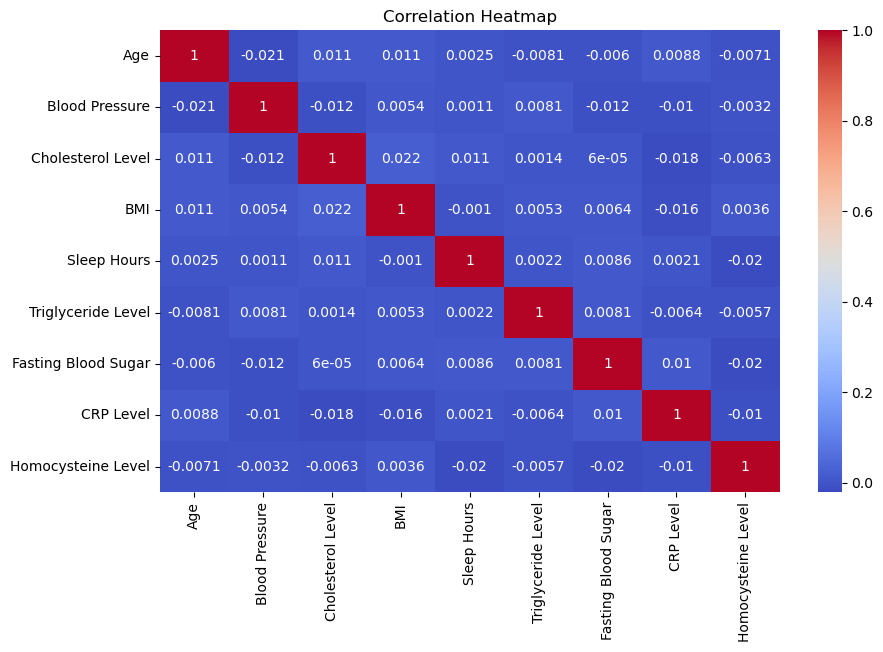

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[nos_col].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Splitting the Dataset

### Dropped Columns 
- Gender → weak impact, not strong alone
- Sugar Consumption → indirect factor (Diabetes already included)
- Alcohol Consumption → inconsistent effect, adds noise
- Low HDL Cholesterol → already included in overall cholesterol
- High LDL Cholesterol → duplicate information (covered in cholesterol)

In [23]:
X = df.drop(['Heart Disease Status','Gender','Sugar Consumption','Alcohol Consumption','Low HDL Cholesterol','High LDL Cholesterol'],axis=1)
y = df['Heart Disease Status']

In [24]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=45)

In [25]:
X_train.shape

(8000, 15)

In [26]:
X_test.shape

(2000, 15)

## Feature Scaling and Train the Model

###  Scaling Numerical Fetures for training data

In [27]:
X_train_nos = X_train.select_dtypes(include=['int64','float64'])
X_train_nos.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
4643,20.0,123.0,256.0,20.963129,8.744954,109.0,108.0,13.252273,16.557277
2390,72.0,180.0,205.0,21.505208,6.671278,331.0,128.0,0.443358,6.548518
6162,33.0,120.0,218.0,24.715567,7.199762,122.0,151.0,7.118393,19.646277
8678,64.0,132.0,221.0,29.715126,5.253874,198.0,113.0,8.130304,10.832558
6944,20.0,164.0,261.0,29.068277,9.075142,266.0,131.0,3.133665,11.257185


### Applyingn Standard Scaler

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_nos_re = pd.DataFrame(scaler.fit_transform(X_train_nos), columns=X_train_nos.columns , index = X_train_nos.index)
X_train_nos_re.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
4643,-1.617752,-1.529229,0.695703,-1.284625,0.998914,-1.638101,-0.514001,1.346696,0.948327
2390,1.238686,1.712751,-0.478673,-1.199078,-0.187778,0.925117,0.336383,-1.619016,-1.370792
6162,-0.903642,-1.699859,-0.179322,-0.692442,0.114655,-1.488002,1.314324,-0.073512,1.664076
8678,0.799234,-1.017337,-0.110241,0.096553,-0.998909,-0.610504,-0.301405,0.160781,-0.378142
6944,-1.617752,0.802722,0.810838,-0.005528,1.187869,0.174625,0.463941,-0.996116,-0.279752


In [29]:
X_train_nos_re.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,2.025047e-16,1.296740e-16,-1.527667e-16,-3.774758e-17,1.989520e-16,-3.685940e-16,-3.219647e-16,6.927792e-17,-3.534950e-16
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.727614e+00,-1.699859e+00,-1.745157e+00,-1.751797e+00,-1.716111e+00,-1.742015e+00,-1.704538e+00,-1.720825e+00,-1.729543e+00
25%,-8.487108e-01,-8.467068e-01,-8.701320e-01,-8.582005e-01,-8.754672e-01,-8.645170e-01,-8.966735e-01,-8.745664e-01,-8.647910e-01
50%,-8.464535e-03,6.445809e-03,4.893476e-03,-4.108723e-03,2.885136e-03,1.435044e-03,-3.770483e-03,4.422365e-03,-2.106079e-03
75%,8.541653e-01,9.164753e-01,8.568920e-01,8.672587e-01,8.790452e-01,8.558410e-01,8.466133e-01,8.608425e-01,8.518993e-01
max,1.678138e+00,1.712751e+00,1.708890e+00,1.719159e+00,1.717106e+00,1.721793e+00,1.696997e+00,1.750530e+00,1.745814e+00


In [30]:
print('Number of Numerical Features:' , scaler.n_features_in_)
print('Mean of each column:' , scaler.mean_)
print('Std of each column:' , np.sqrt(scaler.var_))

Number of Numerical Features: 9
Mean of each column: [ 49.45035175 149.88667076 225.78748952  29.10330433   6.99940993
 250.87571102 120.0886772    7.43589064  12.46452577]
Std of each column: [18.2044963  17.58184835 43.42730701  6.3366157   1.74744192 86.60988023
 23.51879152  4.31900078  4.3157586 ]


### Scaling Categorical Features for training data

In [31]:
X_train_cat = X_train.select_dtypes(include=['object'])
X_train_cat.head()

,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Stress Level
4643,medium,no,yes,yes,yes,high
2390,low,yes,no,no,no,low
6162,medium,yes,no,no,yes,medium
8678,medium,no,yes,yes,yes,low
6944,low,yes,no,no,yes,medium


### Chek  ordinal_cols vs nominal_cols

In [32]:
for col in X_train_cat.columns:
    print(col, ":", X_train_cat[col].unique())

Exercise Habits : ['medium' 'low' 'high']
Smoking : ['no' 'yes']
Family Heart Disease : ['yes' 'no']
Diabetes : ['yes' 'no']
High Blood Pressure : ['yes' 'no']
Stress Level : ['high' 'low' 'medium']


### Appling Ordinal Encoding for oridinal cols for train data

In [33]:
ordinal_cols = ['Exercise Habits','Stress Level']
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[
    ['low', 'medium', 'high'],   # comma lagel
    ['low', 'medium', 'high']
])
X_train_ord = pd.DataFrame(oe.fit_transform(X_train_cat[ordinal_cols]),
                           columns=ordinal_cols,index=X_train_cat.index )

### Applying OneHotEncoding
"One-Hot Encoding was applied to nominal categorical features such as Smoking, Family Heart Disease, Diabetes, and High Blood Pressure to convert them into binary numerical columns. Since these variables have no inherent order, this method prevents introducing misleading relationships between categories."
The get_feature_names_out() method was used to retain meaningful column names after transformation, ensuring better readability and interpretation of the dataset.

In [34]:
nominal_cols = ['Smoking','Family Heart Disease','Diabetes','High Blood Pressure']
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output= False)

# apply Onehotcoder then column name lost becose i am use ( datafram , and get_feature_names_out method) 
X_train_cat_re = pd.DataFrame(encoder.fit_transform(X_train_cat[nominal_cols]) , 
                               columns=encoder.get_feature_names_out(nominal_cols), 
                               index= X_train_cat.index)
X_train_cat_re.head()

,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4643,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2390,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
6162,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
8678,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
6944,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


### Concatinating the ordinal encodeing vs OneHOtencoding for test data

In [35]:
or_vs_no = pd.concat( [X_train_ord,X_train_cat_re],axis = 1)
or_vs_no.head()

,Exercise Habits,Stress Level,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4643,1.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2390,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
6162,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
8678,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
6944,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


In [36]:
encoder.categories_

[array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

### Concatinating the Encoded Categorical Features and Rescaled Numerical Features (Train Data)

In [37]:
X_train_transformed = pd.concat([X_train_nos_re ,or_vs_no ] , axis= 1)
X_train_transformed.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Exercise Habits,Stress Level,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4643,-1.617752,-1.529229,0.695703,-1.284625,0.998914,-1.638101,-0.514001,1.346696,0.948327,1.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2390,1.238686,1.712751,-0.478673,-1.199078,-0.187778,0.925117,0.336383,-1.619016,-1.370792,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
6162,-0.903642,-1.699859,-0.179322,-0.692442,0.114655,-1.488002,1.314324,-0.073512,1.664076,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
8678,0.799234,-1.017337,-0.110241,0.096553,-0.998909,-0.610504,-0.301405,0.160781,-0.378142,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
6944,-1.617752,0.802722,0.810838,-0.005528,1.187869,0.174625,0.463941,-0.996116,-0.279752,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


### Preparing Test Data

In [38]:
X_test.head()

,Age,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Stress Level,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
4132,72.0,170.0,151.0,high,no,yes,no,31.203321,no,high,9.474147,319.0,93.0,0.794361,19.005225
6553,56.0,145.0,292.0,low,yes,yes,yes,19.990787,no,low,4.757255,269.0,128.0,7.616350,19.133876
7604,24.0,159.0,188.0,medium,yes,no,yes,27.913307,no,medium,9.070144,211.0,81.0,9.780935,5.151867
585,23.0,129.0,227.0,medium,no,yes,no,25.469685,yes,medium,8.828465,218.0,143.0,10.689978,12.331073
5924,68.0,130.0,297.0,medium,yes,yes,no,36.590574,yes,high,8.347038,273.0,151.0,14.516391,15.298644


In [39]:
y_test.head()

4132    No
6553    No
7604    No
585     No
5924    No
Name: Heart Disease Status, dtype: object

### Scaling Numerical Features for test data

In [40]:
X_test_nos= X_test.select_dtypes(include= [ 'int64','float64'])
X_test_nos.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
4132,72.0,170.0,151.0,31.203321,9.474147,319.0,93.0,0.794361,19.005225
6553,56.0,145.0,292.0,19.990787,4.757255,269.0,128.0,7.616350,19.133876
7604,24.0,159.0,188.0,27.913307,9.070144,211.0,81.0,9.780935,5.151867
585,23.0,129.0,227.0,25.469685,8.828465,218.0,143.0,10.689978,12.331073
5924,68.0,130.0,297.0,36.590574,8.347038,273.0,151.0,14.516391,15.298644


### Applying Standard Scalar

In [41]:
X_test_nos_re = pd.DataFrame( scaler.transform(X_test_nos) ,
                              columns=X_test_nos.columns , index=X_test_nos.index)
X_test_nos_re.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
4132,1.238686,1.143983,-1.722130,0.331410,1.416206,0.786565,-1.151789,-1.537747,1.515539
6553,0.359782,-0.277938,1.524675,-1.438073,-1.283107,0.209264,0.336383,0.041783,1.545348
7604,-1.398026,0.518337,-0.870132,-0.187797,1.185009,-0.460406,-1.662019,0.542960,-1.694409
585,-1.452957,-1.187968,0.027920,-0.573432,1.046705,-0.379584,0.974171,0.753435,-0.030922
5924,1.018960,-1.131091,1.639809,1.181588,0.771200,0.255448,1.314324,1.639384,0.656691


### Scaling Categorical Features for test data

In [42]:
X_test_cat = X_test.select_dtypes(include=['object'])
X_test_cat.head()

,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Stress Level
4132,high,no,yes,no,no,high
6553,low,yes,yes,yes,no,low
7604,medium,yes,no,yes,no,medium
585,medium,no,yes,no,yes,medium
5924,medium,yes,yes,no,yes,high


### Appling Ordinal Encoding for oridinal cols for test data

In [43]:
X_test_ord = pd.DataFrame(
    oe.transform(X_test_cat[ordinal_cols]),
    columns=ordinal_cols,
    index=X_test_cat.index
)
X_test_ord.head()

,Exercise Habits,Stress Level
4132,2.0,2.0
6553,0.0,0.0
7604,1.0,1.0
585,1.0,1.0
5924,1.0,2.0


### Applying OneHotEncoding

In [44]:
X_test_cat_re = pd.DataFrame(
    encoder.transform(X_test_cat[nominal_cols]),  
    columns=encoder.get_feature_names_out(nominal_cols),
    index=X_test_cat.index
)
X_test_cat_re.head()

,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4132,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6553,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
7604,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
585,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5924,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0


### Concatinating the ordinal encodeing vs OneHOtencoding for test data

In [45]:
or_no_test = pd.concat([X_test_ord,X_test_cat_re],axis=1)
or_no_test.head()

,Exercise Habits,Stress Level,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4132,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6553,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
7604,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
585,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5924,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0


### Concatinating the Encoded Categorical Features and Rescaled Numerical Features(Test Data)

In [46]:
X_test_transformed = pd.concat([X_test_nos_re,or_no_test] , axis=1)
X_test_transformed.head()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Exercise Habits,Stress Level,Smoking_no,Smoking_yes,Family Heart Disease_no,Family Heart Disease_yes,Diabetes_no,Diabetes_yes,High Blood Pressure_no,High Blood Pressure_yes
4132,1.238686,1.143983,-1.722130,0.331410,1.416206,0.786565,-1.151789,-1.537747,1.515539,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
6553,0.359782,-0.277938,1.524675,-1.438073,-1.283107,0.209264,0.336383,0.041783,1.545348,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
7604,-1.398026,0.518337,-0.870132,-0.187797,1.185009,-0.460406,-1.662019,0.542960,-1.694409,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
585,-1.452957,-1.187968,0.027920,-0.573432,1.046705,-0.379584,0.974171,0.753435,-0.030922,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5924,1.018960,-1.131091,1.639809,1.181588,0.771200,0.255448,1.314324,1.639384,0.656691,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0


## SMOTH
- "SMOTE was used to handle class imbalance by generating synthetic samples for the minority class,
-  improving the model’s ability to learn and make balanced predictions."

In [47]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(
    sampling_strategy=0.8,
    k_neighbors=3,
    random_state=42
)

X_train_sm, y_train_sm = sm.fit_resample(X_train_transformed, y_train)

In [48]:
y_train_sm.value_counts()

Heart Disease Status
No     6381
Yes    5104
Name: count, dtype: int64

## Model Select

In [49]:
from sklearn.linear_model import LogisticRegression
Log = LogisticRegression()
Log.fit(X_train_sm ,y_train_sm )

LogisticRegression()

In [50]:
y_prid_Lo = Log.predict(X_test_transformed)

In [51]:
from sklearn.metrics import accuracy_score ,classification_report
print(accuracy_score(y_test,y_prid_Lo))
print(classification_report(y_test,y_prid_Lo))

0.7985
              precision    recall  f1-score   support

          No       0.81      0.98      0.89      1619
         Yes       0.13      0.01      0.02       381

    accuracy                           0.80      2000
   macro avg       0.47      0.50      0.45      2000
weighted avg       0.68      0.80      0.72      2000



In [52]:
from sklearn.metrics import accuracy_score ,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = { 'RandomForestClassifier' : RandomForestClassifier(class_weight = 'balanced',n_estimators=200,max_depth=5),
           'DecisionTreeClassifier' : DecisionTreeClassifier(),
           'SVC' : SVC(probability=True),
           'GaussianNB' : GaussianNB(),
           'KNeighborsClassifier' : KNeighborsClassifier(),
           'LogisticRegression' : LogisticRegression(class_weight='balanced')
         }
           
for name , model in models.items():
    model.fit(X_train_transformed, y_train)

    y_prid = model.predict(X_test_transformed)

    acc = accuracy_score(y_test ,y_prid)
    clas = classification_report(y_test,y_prid)

    print('model:', name)
    print('ACC' ,acc)
    print('CLA' , clas)

model: RandomForestClassifier
ACC 0.614
CLA               precision    recall  f1-score   support

          No       0.82      0.68      0.74      1619
         Yes       0.20      0.35      0.26       381

    accuracy                           0.61      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.70      0.61      0.65      2000

model: DecisionTreeClassifier
ACC 0.663
CLA               precision    recall  f1-score   support

          No       0.81      0.76      0.79      1619
         Yes       0.19      0.24      0.22       381

    accuracy                           0.66      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.69      0.66      0.68      2000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packag

model: SVC
ACC 0.8095
CLA               precision    recall  f1-score   support

          No       0.81      1.00      0.89      1619
         Yes       0.00      0.00      0.00       381

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.66      0.81      0.72      2000

model: GaussianNB
ACC 0.8095
CLA               precision    recall  f1-score   support

          No       0.81      1.00      0.89      1619
         Yes       0.00      0.00      0.00       381

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.66      0.81      0.72      2000

model: KNeighborsClassifier
ACC 0.7825
CLA               precision    recall  f1-score   support

          No       0.81      0.95      0.88      1619
         Yes       0.25      0.07      0.11       381

    accuracy                           0.78      2000
   macro avg       0.53   

In [53]:
from sklearn.metrics import accuracy_score ,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = { 'RandomForestClassifier' : RandomForestClassifier(class_weight = 'balanced',n_estimators=200,max_depth=5),
           'DecisionTreeClassifier' : DecisionTreeClassifier(),
           'SVC' : SVC(probability=True),
           'GaussianNB' : GaussianNB(),
           'KNeighborsClassifier' : KNeighborsClassifier(),
           'LogisticRegression' : LogisticRegression(class_weight='balanced')
         }
           
for name , model in models.items():
    model.fit(X_train_sm,y_train_sm)

    y_prid = model.predict(X_test_transformed)

    acc = accuracy_score(y_test ,y_prid)
    clas = classification_report(y_test,y_prid)

    print('model:', name)
    print('ACC' ,acc)
    print('CLA' , clas)

model: RandomForestClassifier
ACC 0.7525
CLA               precision    recall  f1-score   support

          No       0.82      0.90      0.85      1619
         Yes       0.24      0.14      0.18       381

    accuracy                           0.75      2000
   macro avg       0.53      0.52      0.52      2000
weighted avg       0.71      0.75      0.73      2000

model: DecisionTreeClassifier
ACC 0.6625
CLA               precision    recall  f1-score   support

          No       0.81      0.76      0.78      1619
         Yes       0.20      0.25      0.22       381

    accuracy                           0.66      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.69      0.66      0.68      2000

model: SVC
ACC 0.666
CLA               precision    recall  f1-score   support

          No       0.81      0.77      0.79      1619
         Yes       0.20      0.24      0.22       381

    accuracy                           0.67      2000
   macro avg 

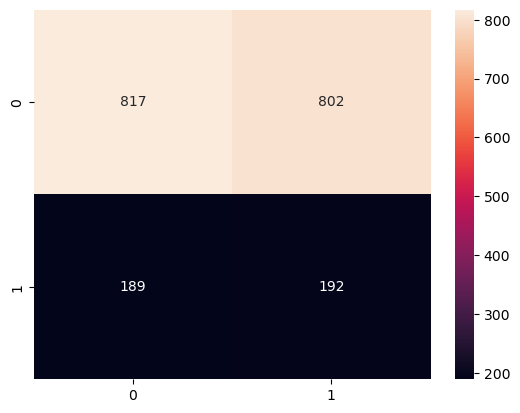

In [54]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_prid), annot=True, fmt='d')
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

y_prob = Log.predict_proba(X_test_transformed)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


ROC-AUC: 0.5062439307501634


### Best Model Selection
"Random Forest performed the best overall due to its ability to handle complex relationships and class imbalance effectively.
Logistic Regression also showed stable and interpretable results."

### Final Conclusion
Random Forest was selected as the best model due to its balanced performance across accuracy, recall, and F1-score. The use of SMOTE significantly improved the model’s ability to detect heart disease cases, making it more suitable for healthcare applications."

### Important Insight
In healthcare problems, recall is more important than accuracy because missing a heart disease case (false negative) can be critical."